In [1]:
import numpy as np
import matplotlib.pyplot as plt


class Nelder_Mead_Optimizer:
    def __init__(
        self,
        x,
        y,
        x0,
        loss,
        max_iter=1000,
        bounds=None,
        treshold=1e-4,
        alpha=1.0,
        beta=0.5,
        gamma=0.5,
        delta=0.05,
    ) -> None:
        # --- Parametri iniziali del ottimizatore
        self.x = x
        self.y = y
        self.x0 = x0
        self.n_dim = len(x0)  # Numero di dimensioni del problema
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.loss = loss
        self.max_iter = max_iter
        self.treshold = treshold
        self.bounds = (
            [(-np.inf, np.inf) for _ in range(self.n_dim)] if bounds is None else bounds
        )

        # --- Parametri secondari per la creazione dei simplessi
        self.delta = delta  # dispersione iniziale dei vertici del simplesso
        self._validate_initial_state()
        self.simplex = self._generate_initial_simplex()  # Simplesso n+1 dimensionale
        self.loss_history = np.array(
            [self.loss(point, self.x, self.y) for point in self.simplex]
        )

    def _generate_initial_simplex(self):
        """Genera il simplesso iniziale, assicurandosi che i vertici siano compresi nei bounds."""
        simplex = np.zeros((self.n_dim + 1, self.n_dim))
        simplex[0] = self.x0

        # Creazione vettorizzata dei punti aggiuntivi del simplesso
        perturbations = self.delta * np.eye(self.n_dim)
        simplex[1:] = self.x0 + perturbations

        # Applicazione dei bounds
        simplex = np.clip(
            simplex, [b[0] for b in self.bounds], [b[1] for b in self.bounds]
        )

        return simplex

    def _validate_initial_state(self) -> None:
        """Valida lo stato iniziale dell'ottimizzatore: numero di dimensioni, bounds e punto iniziale."""
        if len(self.bounds) != self.n_dim:
            raise ValueError(
                "La lunghezza dei bounds non corrisponde al numero di dimensioni."
            )

        for bound in self.bounds:
            if (len(bound) != 2) or (bound[0] > bound[1]):
                raise ValueError("I bounds devono essere coppie di valori (min, max).")
        return None

    def get_vertices(self):
        """
        aggiorna i tre vertici: migliore, peggiore e secondo peggiore e centroide.

        Returns:
        best (np.array): Il miglior vertice (minore valore di loss).
        worst (np.array): Il peggior vertice (maggiore valore di loss).
        second_worst (np.array): Il secondo peggior vertice (secondo maggiore valore di loss).
        indices (tuple): Gli indici dei vertici (best_index, worst_index, second_worst_index).
        """

        # Ordina gli indici dei valori della loss in ordine crescente
        sorted_indices = np.argsort(self.loss_history)

        self.best_index = sorted_indices[0]
        self.worst_index = sorted_indices[-1]
        self.second_worst_index = sorted_indices[-2]

        self.best = self.simplex[self.best_index]
        self.worst = self.simplex[self.worst_index]
        self.second_worst = self.simplex[self.second_worst_index]

        # Calcola il centroide dei migliori vertici (escludendo il peggiore)
        self.centroid = np.mean(
            np.delete(self.simplex, self.worst_index, axis=0), axis=0
        )

    def reflect(self):
        """calcola punto di riflessione"""
        new_point = self.centroid + self.alpha * (self.centroid - self.worst)
        new_point = np.clip(
            new_point, [b[0] for b in self.bounds], [b[1] for b in self.bounds]
        )
        return new_point

    def expand(self, reflect_point):
        """calcola punto di espansione dato punto di riflessione"""
        new_point = self.centroid + self.gamma * (reflect_point - self.centroid)
        new_point = np.clip(
            new_point, [b[0] for b in self.bounds], [b[1] for b in self.bounds]
        )
        return new_point

    def contract(self, point):
        """calcola punto di contrazione dato punto di riflessione e/o contrazione"""
        new_point = self.centroid + self.beta * (point - self.centroid)
        new_point = np.clip(
            new_point, [b[0] for b in self.bounds], [b[1] for b in self.bounds]
        )
        return new_point

    def shrink(self):
        """Riduce il simplesso verso il miglior vertice."""
        self.simplex[1:] = self.best + self.delta * (self.simplex[1:] - self.best)
        self.simplex[1:] = np.clip(
            self.simplex[1:], [b[0] for b in self.bounds], [b[1] for b in self.bounds]
        )
        self.loss_history[1:] = np.apply_along_axis(
            self.compute_loss, 1, self.simplex[1:]
        )

    def compute_loss(self, point):
        """calcola la loss per ogni punto del simplesso"""
        return self.loss(point, self.x, self.y)

    def optimize(self):
        step = 0
        while step < self.max_iter:
            self.get_vertices()  # aggiorno i valori

            reflection = self.reflect()  # calcolo reflection

            loss_best = self.loss_history[self.best_index]
            loss_second_worst = self.loss_history[self.second_worst_index]
            loss_reflection = self.compute_loss(reflection)

            if loss_best < loss_reflection < loss_second_worst:
                self.simplex[self.worst_index] = reflection
                self.loss_history[self.worst_index] = loss_reflection

            elif loss_reflection < loss_best:
                expansion = self.expand(reflection)
                loss_expansion = self.compute_loss(expansion)

                if loss_expansion < loss_reflection:
                    self.simplex[self.worst_index] = expansion
                    self.loss_history[self.worst_index] = loss_expansion
                else:
                    self.simplex[self.worst_index] = reflection
                    self.loss_history[self.worst_index] = loss_reflection

            elif loss_reflection >= loss_second_worst:
                loss_worst = self.loss_history[self.worst_index]
                best_point = self.worst if loss_worst < loss_reflection else reflection

                contraction = self.contract(best_point)
                loss_contraction = self.compute_loss(contraction)

                if loss_contraction < loss_reflection:
                    self.simplex[self.worst_index] = contraction
                    self.loss_history[self.worst_index] = loss_contraction
                else:
                    self.shrink()  # Chiama la funzione di shrink

            # --- termination test
            # print(
            #    f"step {step}, best: {self.simplex[self.best_index]}, loss history: {self.loss_history}"
            # )

            step += 1
            if step >= self.max_iter:
                print("Raggiunto numero massimo di iterazioni")
                break
            if np.max(self.loss_history) - np.min(self.loss_history) < self.treshold:
                print("Treshold raggiunta")
                break

        return self.simplex[self.best_index]

Dati generati (x, y):
[-8.55       -8.15969697 -7.76939394 -7.37909091 -6.98878788 -6.59848485
 -6.20818182 -5.81787879 -5.42757576 -5.03727273] [-0.10033969  0.13076887  0.08593219 -0.0003807   0.1464262   0.06620418
 -0.06711939  0.10951365  0.05774394 -0.08391823]
Punto iniziale: [0.6, 1.5, 0.5]


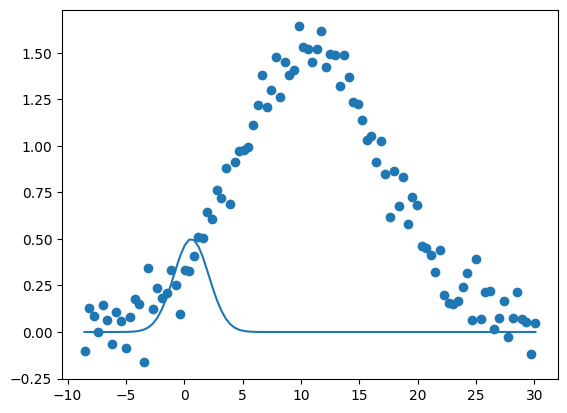

In [2]:

# Definizione della Gaussiana 1D
def gaussian_1d(x, mu, sigma, A):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma**2))


# Funzione di loss (MSE)
def loss(params, x, y):
    mu, sigma, A = params
    y_pred = gaussian_1d(x, mu, sigma, A)
    return np.mean((y - y_pred) ** 2)


# Generazione di dati finti
def generate_fake_data(mu, sigma, A, num_points=100, noise_level=0.1):
    x = np.linspace(mu - 3 * sigma, mu + 3 * sigma, num_points)
    y_true = gaussian_1d(x, mu, sigma, A)
    noise = noise_level * np.random.randn(num_points)
    y_noisy = y_true + noise
    return x, y_noisy


# Parametri veri per la generazione dei dati finti
true_mu = 10.77
true_sigma = 6.44
true_A = 1.5

# Genera dati finti
x_data, y_data = generate_fake_data(true_mu, true_sigma, true_A)

# Punto iniziale per l'algoritmo di Nelder-Mead
initial_guess = [0.6, 1.5, 0.5]  # [mu, sigma, A]

print("Dati generati (x, y):")
print(x_data[:10], y_data[:10])  # Stampa i primi 10 dati per esempio
print("Punto iniziale:", initial_guess)


plt.scatter(x_data, y_data)
plt.plot(x_data, gaussian_1d(x_data,*initial_guess))

In [3]:
bounds = [(-11,11), (-11,11), (-11,11)]
optim = Nelder_Mead_Optimizer(x_data, y_data, bounds = bounds,x0=initial_guess, loss=loss, delta=0.3, max_iter=10000)

print("simplesso iniziale\n", optim.simplex)

best_results = optim.optimize()

print(best_results)

simplesso iniziale
 [[0.6 1.5 0.5]
 [0.9 1.5 0.5]
 [0.6 1.8 0.5]
 [0.6 1.5 0.8]]
Treshold raggiunta
[10.90620618  6.31111059  1.5264283 ]


Parametri ottimizzati (mu, sigma, A): [10.82577156  6.34089917  1.51370273]


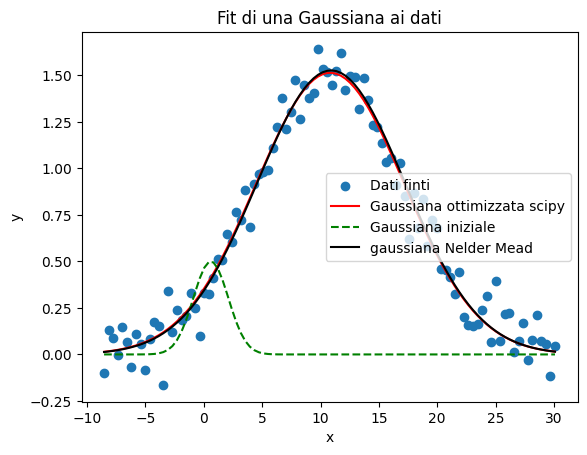

In [4]:
from scipy.optimize import minimize

result = minimize(loss, initial_guess, bounds=None, args=(x_data, y_data), method="Nelder-Mead")
optimized_params = result.x

print("Parametri ottimizzati (mu, sigma, A):", optimized_params)

# Grafico dei dati originali e della curva ottimizzata
plt.scatter(x_data, y_data, label="Dati finti")
plt.plot(
    x_data,
    gaussian_1d(x_data, *optimized_params),
    color="red",
    label="Gaussiana ottimizzata scipy",
)
plt.plot(
    x_data,
    gaussian_1d(x_data, *initial_guess),
    color="green",
    linestyle="--",
    label="Gaussiana iniziale",
)

plt.plot(x_data, gaussian_1d(x_data, *best_results), c='black', label='gaussiana Nelder Mead')

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Fit di una Gaussiana ai dati")
plt.show()

In [5]:
from scipy.optimize import OptimizeResult

class NelderMead:
    def __init__(
        self,
        treshold=1e-4,
        alpha=1.0,
        beta=0.5,
        gamma=0.5,
        delta=0.05,
    ):
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.treshold = treshold
        self.delta = delta  # dispersione iniziale dei vertici del simplesso

   
        

    def _generate_initial_simplex(self, n_dim, x0, bounds):
        """Genera il simplesso iniziale, assicurandosi che i vertici siano compresi nei bounds.
        x0 --> punto iniziale
        n_dim --> numero di dimensioni del hyperspazio (len(x0))
        """
        simplex = np.zeros((n_dim + 1, n_dim))
        simplex[0] = x0

        # Creazione vettorizzata dei punti aggiuntivi del simplesso
        perturbations = self.delta * np.eye(n_dim)
        simplex[1:] = x0 + perturbations

        # Applicazione dei bounds
        simplex = np.clip(simplex, [b[0] for b in bounds], [b[1] for b in bounds])

        return simplex

    def reflect(self, bounds):
        """calcola punto di riflessione"""
        new_point = self.centroid + self.alpha * (self.centroid - self.worst)
        new_point = np.clip(new_point, [b[0] for b in bounds], [b[1] for b in bounds])
        return new_point

    def expand(self, reflect_point, bounds):
        """calcola punto di espansione dato punto di riflessione"""
        new_point = self.centroid + self.gamma * (reflect_point - self.centroid)
        new_point = np.clip(new_point, [b[0] for b in bounds], [b[1] for b in bounds])
        return new_point

    def contract(self, point, bounds):
        """calcola punto di contrazione dato punto di riflessione e/o contrazione"""
        new_point = self.centroid + self.beta * (point - self.centroid)
        new_point = np.clip(new_point, [b[0] for b in bounds], [b[1] for b in bounds])
        return new_point

    def shrink(self, bounds):
        """Riduce il simplesso verso il miglior vertice."""
        self.simplex[1:] = self.best + self.delta * (self.simplex[1:] - self.best)
        self.simplex[1:] = np.clip(
            self.simplex[1:], [b[0] for b in bounds], [b[1] for b in bounds]
        )
        self.loss_history[1:] = np.apply_along_axis(
            self.compute_loss, 1, self.simplex[1:]
        )

    def get_vertices(self):
        """
        aggiorna i tre vertici: migliore, peggiore e secondo peggiore e centroide.

        Returns:
        best (np.array): Il miglior vertice (minore valore di loss).
        worst (np.array): Il peggior vertice (maggiore valore di loss).
        second_worst (np.array): Il secondo peggior vertice (secondo maggiore valore di loss).
        indices (tuple): Gli indici dei vertici (best_index, worst_index, second_worst_index).
        """

        # Ordina gli indici dei valori della loss in ordine crescente
        sorted_indices = np.argsort(self.loss_history)

        self.best_index = sorted_indices[0]
        self.worst_index = sorted_indices[-1]
        self.second_worst_index = sorted_indices[-2]

        self.best = self.simplex[self.best_index]
        self.worst = self.simplex[self.worst_index]
        self.second_worst = self.simplex[self.second_worst_index]

        # Calcola il centroide dei migliori vertici (escludendo il peggiore)
        self.centroid = np.mean(
            np.delete(self.simplex, self.worst_index, axis=0), axis=0
        )

    def optimize(
        self,
        func,
        x0,
        args,
        bounds=None,
        maxiter=None,
        
        calculate_errors=False,
    ):
        """
        maxfun --> numero max di call di funzione
        """
        # --- inizializazzione della funzione
        x0 = np.asfarray(x0).flatten()  # converte in float e lo flatterizza
        N = len(x0)
        self.n_dim = N
        rank = len(np.shape(x0))

        constrains = [(-np.inf, np.inf) for _ in range(N)] if bounds is None else bounds
        # --- aggiungere un controllo sui bounds?

        # --- funzione di loss wrappata per gestire solo i punti da minimizzare
        def wrapped_loss(x):
            return func(x, *args)

        if not -1 < rank < 2:
            raise ValueError("Initial guess must be a scalar or rank-1 sequence.")
        if maxiter is None:
            maxiter = N * 300
        

        # --- genero simplesso iniziale
        self.simplex = self._generate_initial_simplex(N, x0, constrains)

        # --- genero array dei valori di loss
        self.loss_history = np.array([wrapped_loss(point) for point in self.simplex])
        # ------------------------------------------------------------
        # --- inizio del loop
        iters = 0
        while iters < maxiter:
            self.get_vertices()  # aggiorno i valori

            reflection = self.reflect(bounds=constrains)  # calcolo reflection

            loss_best = self.loss_history[self.best_index]
            loss_second_worst = self.loss_history[self.second_worst_index]
            loss_reflection = wrapped_loss(reflection)

            if loss_best < loss_reflection < loss_second_worst:
                self.simplex[self.worst_index] = reflection
                self.loss_history[self.worst_index] = loss_reflection

            elif loss_reflection < loss_best:
                expansion = self.expand(reflection, bounds=constrains)
                loss_expansion = wrapped_loss(expansion)

                if loss_expansion < loss_reflection:
                    self.simplex[self.worst_index] = expansion
                    self.loss_history[self.worst_index] = loss_expansion
                else:
                    self.simplex[self.worst_index] = reflection
                    self.loss_history[self.worst_index] = loss_reflection

            elif loss_reflection >= loss_second_worst:
                loss_worst = self.loss_history[self.worst_index]
                best_point = self.worst if loss_worst < loss_reflection else reflection

                contraction = self.contract(best_point, bounds=constrains)
                loss_contraction = wrapped_loss(contraction)

                if loss_contraction < loss_reflection:
                    self.simplex[self.worst_index] = contraction
                    self.loss_history[self.worst_index] = loss_contraction
                else:
                    self.shrink(bounds=constrains)  # Chiama la funzione di shrink

            iters += 1
            if np.max(self.loss_history) - np.min(self.loss_history) < self.treshold:
                print("Treshold raggiunta")
                
                break
        """
        if calculate_errors is True:
            errors = self._compute_errors(self.simplex, self.loss_history, wrapped_loss)
        else:
            errors = None
        """
        
        return self.simplex[self.best_index]

Treshold raggiunta
Parametri ottimizzati (mu, sigma, A): [-1.84975578e+04  2.42403508e+05  6.27172919e-01] [10.62339901  6.47949405  1.5043634 ]


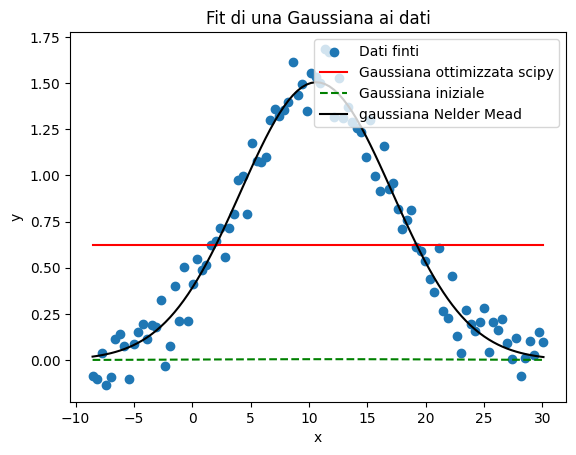

In [6]:
from scipy.optimize import minimize


# Definizione della Gaussiana 1D
def gaussian_1d(x, mu, sigma, A):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma**2))


# Funzione di loss (MSE)
def loss(params, x, y):
    mu, sigma, A = params
    y_pred = gaussian_1d(x, mu, sigma, A)
    return np.mean((y - y_pred) ** 2)


# Generazione di dati finti
def generate_fake_data(mu, sigma, A, num_points=100, noise_level=0.1):
    x = np.linspace(mu - 3 * sigma, mu + 3 * sigma, num_points)
    y_true = gaussian_1d(x, mu, sigma, A)
    noise = noise_level * np.random.randn(num_points)
    y_noisy = y_true + noise
    return x, y_noisy


# Parametri veri per la generazione dei dati finti
true_mu = 10.77
true_sigma = 6.44
true_A = 1.5

# Genera dati finti
x_data, y_data = generate_fake_data(true_mu, true_sigma, true_A)

# Punto iniziale per l'algoritmo di Nelder-Mead
initial_guess = [11.6, 11.5, 0.005]  # [mu, sigma, A]

optimizer = NelderMead(treshold=1e-6, delta=0.1)

miei_results = optimizer.optimize(
    loss,
    initial_guess,
    args=(x_data, y_data),
    bounds=None,
    maxiter=1e6,
    calculate_errors=False,
)

result = minimize(
    loss, initial_guess, bounds=None, args=(x_data, y_data), method="Nelder-Mead"
)
optimized_params = result.x

print("Parametri ottimizzati (mu, sigma, A):", optimized_params, miei_results)


# Grafico dei dati originali e della curva ottimizzata
plt.scatter(x_data, y_data, label="Dati finti")
plt.plot(
    x_data,
    gaussian_1d(x_data, *optimized_params),
    color="red",
    label="Gaussiana ottimizzata scipy",
)
plt.plot(
    x_data,
    gaussian_1d(x_data, *initial_guess),
    color="green",
    linestyle="--",
    label="Gaussiana iniziale",
)

plt.plot(
    x_data, gaussian_1d(x_data, *miei_results), c="black", label="gaussiana Nelder Mead"
)

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Fit di una Gaussiana ai dati")
plt.show()

In [7]:
import scipy

x0 = [1.3, 0.7, 0.8, 1.9, 1.2]
res = scipy.optimize.minimize(scipy.optimize.rosen, x0, method="Nelder-Mead",options={'maxiter':1e6})
print(res)


miei = optimizer.optimize(scipy.optimize.rosen, x0, args=(), maxiter=1e4)

print(miei)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 6.617481708884532e-05
             x: [ 9.991e-01  9.982e-01  9.965e-01  9.930e-01  9.860e-01]
           nit: 141
          nfev: 243
 final_simplex: (array([[ 9.991e-01,  9.982e-01, ...,  9.930e-01,
                         9.860e-01],
                       [ 9.991e-01,  9.982e-01, ...,  9.930e-01,
                         9.861e-01],
                       ...,
                       [ 9.991e-01,  9.982e-01, ...,  9.929e-01,
                         9.860e-01],
                       [ 9.991e-01,  9.982e-01, ...,  9.930e-01,
                         9.860e-01]]), array([ 6.617e-05,  6.643e-05,  6.666e-05,  6.694e-05,
                        6.707e-05,  6.709e-05]))
[1.00684885 1.01392138 1.02807268 1.05685036 1.11756478]
